## Exercise Solution — UdaciBank Portfolio KRI Calculator

This is the reference solution. Both KRI calculators are implemented; both unit tests pass; the 5-KRI dashboard renders to `kri_dashboard.png`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timezone

DATA = Path("../starter/data")
np.random.seed(42)

## 1. KRI #1 — Subgroup FNR delta (Fraud model)

In [2]:
def status_band(value, green, red):
    if value <= green: return "green"
    if value <= red:   return "amber"
    return "red"


def compute_subgroup_fnr_delta(df, label_col="label", pred_col="prediction",
                               group_cols=("region", "income_tier"),
                               green=0.05, red=0.10,
                               owner="Fraud Model Owner"):
    # Note: include_groups=False avoids pandas 2.2+ FutureWarning about apply on grouping cols.
    grouped = df.groupby(list(group_cols))[[label_col, pred_col]]
    fnr = grouped.apply(
        lambda g: float(((g[label_col] == 1) & (g[pred_col] == 0)).sum() /
                        max(1, (g[label_col] == 1).sum())),
        include_groups=False,
    )
    value = round(float(fnr.max() - fnr.min()), 4)
    return {
        "value": value,
        "status": status_band(value, green, red),
        "owner": owner,
        "timestamp": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    }


fraud = pd.read_csv(DATA / "fraud_predictions.csv", parse_dates=["date"])
result_kri1 = compute_subgroup_fnr_delta(fraud)
print(result_kri1)
assert abs(result_kri1["value"] - 0.1053) < 0.005
assert result_kri1["status"] == "red"
print("KRI #1 PASS")

{'value': 0.1053, 'status': 'red', 'owner': 'Fraud Model Owner', 'timestamp': '2026-05-15T15:17:16+00:00'}
KRI #1 PASS


## 2. KRI #2 — Feature drift (max PSI)

In [3]:
def population_stability_index(baseline, current, bins=10):
    baseline = np.asarray(baseline, dtype=float)
    current  = np.asarray(current,  dtype=float)
    edges = np.linspace(min(baseline.min(), current.min()),
                        max(baseline.max(), current.max()),
                        bins + 1)
    b_hist, _ = np.histogram(baseline, bins=edges)
    c_hist, _ = np.histogram(current,  bins=edges)
    b_pct = (b_hist + 1e-6) / (b_hist.sum() + 1e-6 * bins)
    c_pct = (c_hist + 1e-6) / (c_hist.sum() + 1e-6 * bins)
    return float(np.sum((c_pct - b_pct) * np.log(c_pct / b_pct)))


def compute_drift_score(df, snapshot_col="snapshot",
                        feature_cols=("debt_to_income", "credit_age_years",
                                      "recent_inquiries", "utilization"),
                        green=0.10, red=0.25,
                        owner="Credit Model Owner"):
    baseline = df[df[snapshot_col] == "baseline"]
    current  = df[df[snapshot_col] == "current"]
    psi_per_feature = {
        col: population_stability_index(baseline[col], current[col])
        for col in feature_cols
    }
    value = round(max(psi_per_feature.values()), 4)
    return {
        "value": value,
        "status": status_band(value, green, red),
        "owner": owner,
        "timestamp": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "per_feature": psi_per_feature,
    }


drift = pd.read_csv(DATA / "credit_drift_features.csv")
result_kri2 = compute_drift_score(drift)
print(result_kri2)
assert result_kri2["value"] >= 0.25
assert result_kri2["status"] == "red"
print("KRI #2 PASS")

{'value': 1.964, 'status': 'red', 'owner': 'Credit Model Owner', 'timestamp': '2026-05-15T15:17:16+00:00', 'per_feature': {'debt_to_income': 1.963966364955598, 'credit_age_years': 0.0011200324900844294, 'recent_inquiries': 0.07262410316146917, 'utilization': 0.4118732943673982}}
KRI #2 PASS


## 3. Render the 5-KRI dashboard

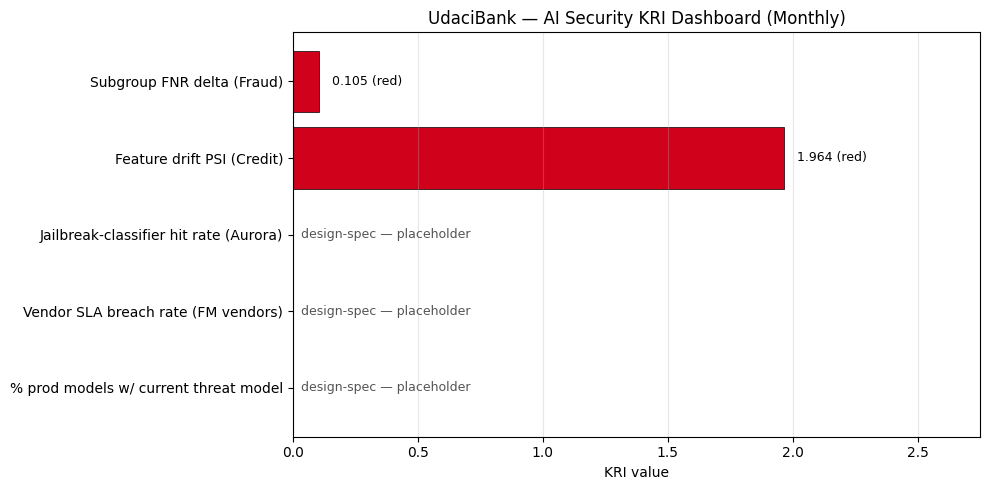

Saved kri_dashboard.png


In [4]:
dashboard = [
    {"kri": "Subgroup FNR delta (Fraud)",           "value": result_kri1["value"], "status": result_kri1["status"], "amber": 0.05,  "red": 0.10},
    {"kri": "Feature drift PSI (Credit)",           "value": result_kri2["value"], "status": result_kri2["status"], "amber": 0.10,  "red": 0.25},
    {"kri": "Jailbreak-classifier hit rate (Aurora)", "value": None,                "status": "design-spec",         "amber": 0.0005, "red": 0.002},
    {"kri": "Vendor SLA breach rate (FM vendors)",  "value": None,                  "status": "design-spec",         "amber": 0.001, "red": 0.005},
    {"kri": "% prod models w/ current threat model","value": None,                  "status": "design-spec",         "amber": 0.90,  "red": 0.70},
]

color_map = {"green": "#5BBA6F", "amber": "#F5A623", "red": "#D0021B", "design-spec": "#B8B8B8"}

fig, ax = plt.subplots(figsize=(10, 5))
labels = [d["kri"] for d in dashboard]
values = [d["value"] if d["value"] is not None else 0 for d in dashboard]
colors = [color_map[d["status"]] for d in dashboard]

bars = ax.barh(labels, values, color=colors, edgecolor="black", linewidth=0.5)

# Status / value labels
for d, bar in zip(dashboard, bars):
    if d["value"] is None:
        ax.text(0.001, bar.get_y() + bar.get_height()/2,
                "  design-spec — placeholder", va="center", fontsize=9, color="#555")
    else:
        ax.text(bar.get_width() + max(values)*0.01,
                bar.get_y() + bar.get_height()/2,
                f"  {d['value']:.3f} ({d['status']})", va="center", fontsize=9)

ax.set_xlabel("KRI value")
ax.set_title("UdaciBank — AI Security KRI Dashboard (Monthly)")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(0, max(values) * 1.4)
plt.tight_layout()
plt.savefig("kri_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved kri_dashboard.png")

## 4. Summary

| KRI | Value | Status | Action |
|---|---|---|---|
| Subgroup FNR delta (Fraud) | 0.105 | **Red** | Escalate to CRO; spin up subgroup-fairness investigation on M-01 FraudShield. |
| Feature drift PSI (Credit) | ~1.96 | **Red** | Trigger M-02 CreditDecision retrain; investigate utilization + DTI distribution shift. |
| Jailbreak-classifier hit rate (Aurora) | — | design-spec | Wire LLM-gateway jailbreak_flag pipe into dashboard (next sprint). |
| Vendor SLA breach rate | — | design-spec | Wire vendor-SLA monitor (next sprint). |
| % models w/ current threat model | — | design-spec | Enforce model-registry tagging; first reading at end of next sprint. |

The dashboard ships immediately with two live KRIs and three design-spec placeholders — the AIRB sees the intended portfolio shape from day one.